In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_csv(
    r"E:\DataVisualization\SuperStoreDatasetProject\Dataset\Sample - Superstore.csv",
    encoding="latin1"   
)

## 1. Dataset Copy

In [4]:
df_clean = df.copy()

## 2. Check Missing Values

In [5]:
df_clean.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## 3. Missing Value Percentage

In [6]:
(df_clean.isnull().sum() / len(df_clean)) * 100

Row ID           0.0
Order ID         0.0
Order Date       0.0
Ship Date        0.0
Ship Mode        0.0
Customer ID      0.0
Customer Name    0.0
Segment          0.0
Country          0.0
City             0.0
State            0.0
Postal Code      0.0
Region           0.0
Product ID       0.0
Category         0.0
Sub-Category     0.0
Product Name     0.0
Sales            0.0
Quantity         0.0
Discount         0.0
Profit           0.0
dtype: float64

## 4. Duplicate Records

In [7]:
df_clean.duplicated().sum()

np.int64(0)

## 5. Remove Duplicates

In [8]:
df_clean = df_clean.drop_duplicates()

## 6. Check Data Types

In [9]:
df_clean.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

## 7. Convert Date Columns

In [10]:
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'])
df_clean['Ship Date'] = pd.to_datetime(df_clean['Ship Date'])

## 8. Rename Columns (Optional)

Column names ko consistent banana:

In [12]:
df_clean.columns = (df_clean.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_"))

## 9. Check Outliers

In [15]:
df_clean.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='str')

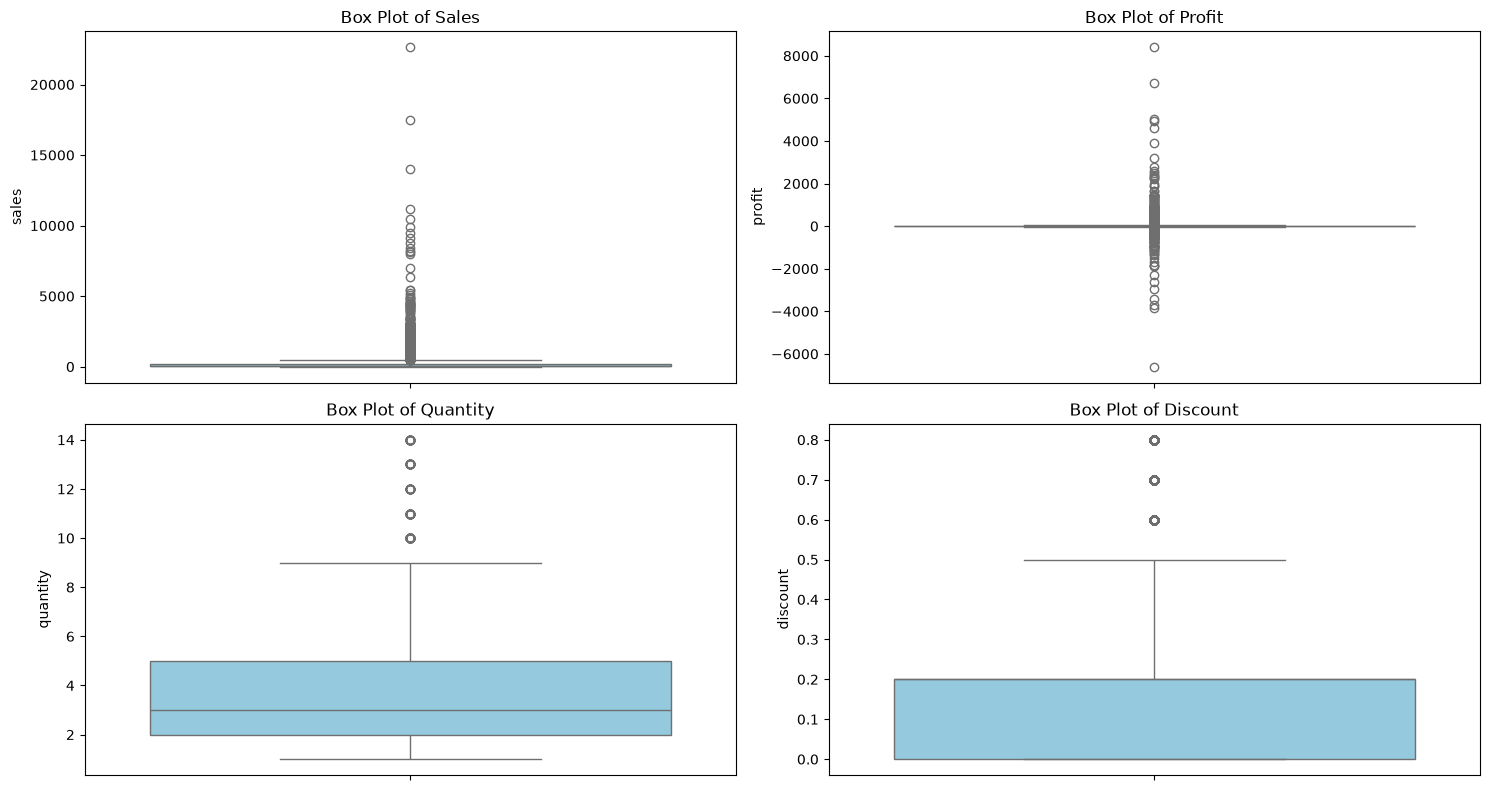

In [16]:
# Numerical columns
numerical_columns = ['sales', 'profit', 'quantity', 'discount']

# Box Plot
plt.figure(figsize=(15, 8))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df_clean[column], color='skyblue')
    plt.title(f'Box Plot of {column.title()}')

plt.tight_layout()
plt.show()

### Observation

- Sales column contains several high-value outliers.
- Profit has both positive and negative outliers.
- Quantity contains a few extreme values.
- Discount has limited unique values and shows fewer outliers.

These outliers may represent genuine business transactions rather than data entry errors, so they will not be removed at this stage.

## 10. Final Validation

### Shape

In [17]:
df_clean.shape

(9994, 21)

### Missing Values

In [18]:
df_clean.isnull().sum()

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub_category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64

### Duplicate Records

In [19]:
df_clean.duplicated().sum()

np.int64(0)

### Data Types

In [20]:
df_clean.dtypes

row_id                    int64
order_id                    str
order_date       datetime64[us]
ship_date        datetime64[us]
ship_mode                   str
customer_id                 str
customer_name               str
segment                     str
country                     str
city                        str
state                       str
postal_code               int64
region                      str
product_id                  str
category                    str
sub_category                str
product_name                str
sales                   float64
quantity                  int64
discount                float64
profit                  float64
dtype: object

### Dataset Information

In [21]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   str           
 2   order_date     9994 non-null   datetime64[us]
 3   ship_date      9994 non-null   datetime64[us]
 4   ship_mode      9994 non-null   str           
 5   customer_id    9994 non-null   str           
 6   customer_name  9994 non-null   str           
 7   segment        9994 non-null   str           
 8   country        9994 non-null   str           
 9   city           9994 non-null   str           
 10  state          9994 non-null   str           
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   str           
 13  product_id     9994 non-null   str           
 14  category       9994 non-null   str           
 15  sub_category   9994 non-null   s

### First Five Rows

In [22]:
df_clean.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Save Clean Dataset

In [24]:
df_clean.to_csv(
    r"E:\DataVisualization\SuperStoreDatasetProject\Dataset\clean_superstore.csv",
    index=False
)

# Data Cleaning Summary

### Tasks Performed

- Loaded the dataset
- Created a copy of the original dataset
- Checked missing values
- Checked duplicate records
- Verified data types
- Converted date columns
- Standardized column names (if applied)
- Visualized outliers using box plots
- Performed final validation
- Saved the cleaned dataset

### Result

The dataset is now clean and ready for Exploratory Data Analysis (EDA).